### 网络架构
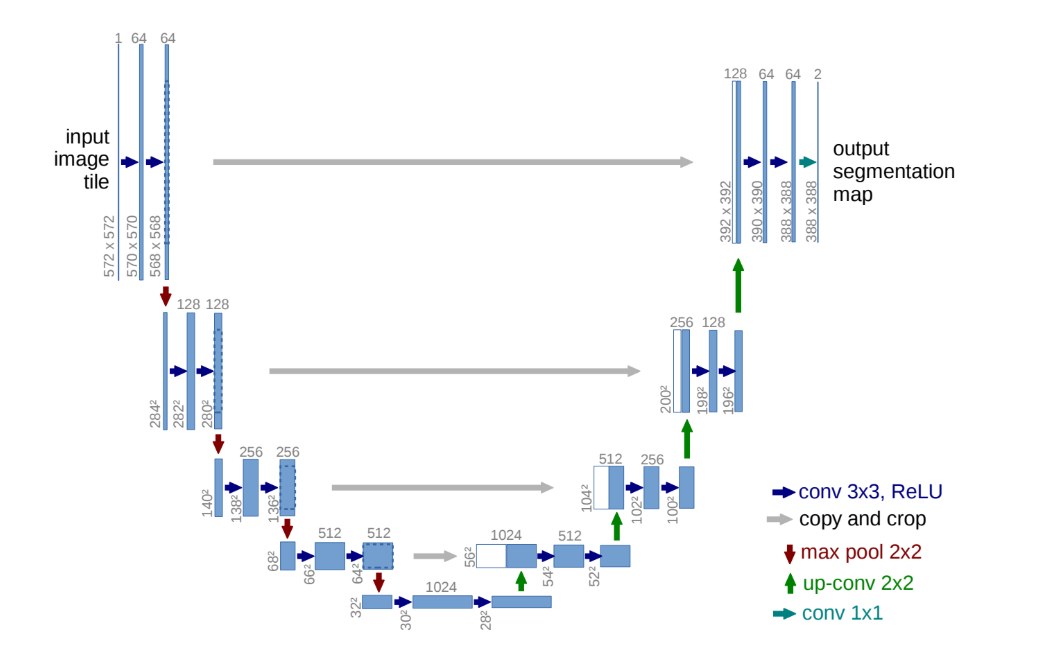

### 代码实现

In [2]:
import torch
import torch.nn as nn 

# 定义两个连续3x3卷积操作
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False), 
            nn.BatchNorm2d(out_channels), 
            nn.ReLU(inplace=True), 
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), 
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)
        
        

In [3]:
# 定义U_Net
class U_Net(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # 编码路径
        self.conv1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.conv3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2)
        self.conv4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2)
        self.conv5 = DoubleConv(512, 1024) # 最底层

        # 解码路径
        self.up6 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv6 = DoubleConv(1024, 512) # 拼接后变为1024

        self.up7 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv7 = DoubleConv(512, 256)

        self.up8 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv8 = DoubleConv(256, 128)

        self.up9 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv9 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # 编码
        c1 = self.conv1(x)
        p1 = self.pool1(c1) 
        c2 = self.conv2(p1)
        p2 = self.pool2(c2)
        c3 = self.conv3(p2)
        p3 = self.pool3(c3)
        c4 = self.conv4(p3)
        p4 = self.pool4(c4)
        c5 = self.conv5(p4)

        # 解码
        up6 = self.up6(c5)
        up6 = torch.cat([c4, up6], dim=1)
        c6 = self.conv6(up6)

        up7 = self.up7(c6)
        up7 = torch.cat([c3, up7], dim=1)
        c7 = self.conv7(up7)

        up8 = self.up8(c7)
        up8 = torch.cat([c2, up8], dim=1)
        c8 = self.conv8(up8)

        up9 = self.up9(c8)
        up9 = torch.cat([c1, up9], dim=1)
        c9 = self.conv9(up9)

        output = self.final_conv(c9)
        return output


In [5]:
# 测试U_Net
if __name__ == "__main__":
    model = U_Net(in_channels=3, out_channels=1)
    x = torch.randn(1, 3, 512, 512)  # 输入一个随机张量
    output = model(x)
    print(output.shape)  # 输出的形状

torch.Size([1, 1, 512, 512])
